## Summary
1. train data 487개로 학습
2. test1 = 팀원1, test2 = 팀원 2
3. 처음에 모든 사진을 보 (class 2)로 예측해 정확도 약 33%
4. 이미지 사이즈 (512, 512)로 바꿔서 다시 시도 (기존 96x96)
5. Conv 블록을 더 깊게 + 필터 수를 늘림
6. batch_size를 줄임
7. train data에서도 정확도가 매우 떨어짐 (약 0.35)
8. test data에서는 test1은 0.33, test2는 0.55로 상승

In [11]:
# Imports

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [12]:
from PIL import Image 
import glob
import os

In [ ]:
# Resize images

target_size = (96, 96)

def resize_images(dir_path):
    image_paths = glob.glob(os.path.join(dir_path, '*.jpg'))
    print(len(image_paths), 'images to be resized in', dir_path)

    for image_path in image_paths:
        with Image.open(image_path) as image:
            image = image.convert('RGB')
            resized_image = image.resize(target_size, Image.Resampling.LANCZOS)
            resized_image.save(image_path, 'JPEG')

    print(len(image_paths), 'images resized to', target_size)

train_root = os.path.join(os.getcwd(), 'train')

resize_images(os.path.join(train_root, 'scissors'))
resize_images(os.path.join(train_root, 'rock'))
resize_images(os.path.join(train_root, 'paper'))


178 images to be resized in /Users/corinnekim/practice/rock-paper-scissors/train/scissors
178 images resized to (96, 96)
162 images to be resized in /Users/corinnekim/practice/rock-paper-scissors/train/rock
162 images resized to (96, 96)
147 images to be resized in /Users/corinnekim/practice/rock-paper-scissors/train/paper
147 images resized to (96, 96)


In [18]:
def load_data(root_dir, img_size=96):
    class_to_label = {'scissors': 0, 'rock': 1, 'paper': 2}

    images = []
    labels = []

    for class_name, label in class_to_label.items():
        class_dir = os.path.join(root_dir, class_name)
        image_paths = sorted(glob.glob(os.path.join(class_dir, '*.jpg')))

        for image_path in image_paths:
            with Image.open(image_path) as image:
                image = image.convert('RGB')
                if image.size != (img_size, img_size):
                    try:
                        image = image.resize((img_size, img_size), Image.Resampling.LANCZOS)
                    except AttributeError:
                        image = image.resize((img_size, img_size), Image.LANCZOS)

                images.append(np.asarray(image, dtype=np.uint8))
                labels.append(label)

    if len(images) == 0:
        raise ValueError('No images found. Check ./train/{scissors,rock,paper} and jpg files.')

    x = np.stack(images, axis=0)                 # uint8, 0~255
    y = np.asarray(labels, dtype=np.int8)       # 0/1/2

    print('Number of images:', x.shape[0])
    print('Label counts:', np.bincount(y, minlength=3))
    return x, y

train_root = os.path.join(os.getcwd(), 'train')  # ./train
x_train, y_train = load_data(train_root, img_size=96)

x_train_norm = x_train.astype(np.float32) / 255.0

print('x_train shape:', x_train.shape, x_train.dtype, x_train.min(), x_train.max())
print('x_train_norm shape:', x_train_norm.shape, x_train_norm.dtype, x_train_norm.min(), x_train_norm.max())
print('y_train shape:', y_train.shape, y_train.dtype, np.unique(y_train))


Number of images: 487
Label counts: [178 162 147]
x_train shape: (487, 96, 96, 3) uint8 0 255
x_train_norm shape: (487, 96, 96, 3) float32 0.0 1.0
y_train shape: (487,) int8 [0 1 2]


Label: 0


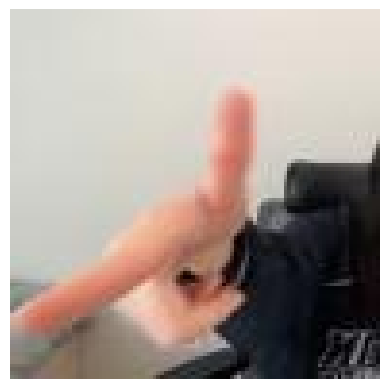

In [15]:
plt.imshow(x_train_norm[0])
plt.axis('off')
print('Label:', y_train[0])

In [19]:
from tensorflow import keras

# Build the model
n_channel_1 = 16
n_channel_2 = 32
n_dense = 32
n_train_epoch = 10

input_shape = x_train_norm.shape[1:]

model = keras.Sequential([
    keras.layers.Input(shape=input_shape),

    keras.layers.Conv2D(n_channel_1, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(n_channel_2, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(n_dense, activation='relu'),

    keras.layers.Dense(3, activation='softmax'),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 94, 94, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 47, 47, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 45, 45, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │       495,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,835 (1.91 MB)

 Trainable params: 500,835 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train_norm,
    y_train,
    epochs=n_train_epoch,
    shuffle=True
)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5318 - loss: 0.9761
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8809 - loss: 0.4916
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9877 - loss: 0.1216
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0278
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0099
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0084
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0063
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0039
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0020
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0018


In [25]:
# Load test data (team member 1)
test1_root = os.path.join(os.getcwd(), 'test1')

x_test1, y_test1 = load_data(test1_root, img_size=96)

x_test1 = x_test1.astype(np.float32)
x_test1_norm = x_test1 / 255.0

print('x_test1 shape:', x_test1_norm.shape)
print('y_test1 shape:', y_test1.shape)
print('y_test1 counts:', np.bincount(y_test1, minlength=3))


Number of images: 300
Label counts: [100 100 100]
x_test1 shape: (300, 96, 96, 3)
y_test1 shape: (300,)
y_test1 counts: [100 100 100]


In [30]:
# Load test data (team member 2)
test2_root = os.path.join(os.getcwd(), 'test2')

x_test2, y_test2 = load_data(test2_root, img_size=96)

x_test2 = x_test2.astype(np.float32)
x_test2_norm = x_test2 / 255.0

print('x_test2 shape:', x_test2_norm.shape)
print('y_test2 shape:', y_test2.shape)
print('y_test2 counts:', np.bincount(y_test2, minlength=3))

Number of images: 325
Label counts: [101 113 111]
x_test2 shape: (325, 96, 96, 3)
y_test2 shape: (325,)
y_test2 counts: [101 113 111]


In [31]:
# Evaluate on test set (team member 1)
loss_1, acc_1 = model.evaluate(x_test1_norm, y_test1, verbose=2)
print('test1 accuracy:', acc_1)

# Evaluate on test set (team member 2)
loss_2, acc_2 = model.evaluate(x_test2_norm, y_test2, verbose=2)
print('test2 accuracy:', acc_2)


10/10 - 0s - 9ms/step - accuracy: 0.3300 - loss: 6.7183
test1 accuracy: 0.33000001311302185
11/11 - 0s - 7ms/step - accuracy: 0.3415 - loss: 4.7806
test2 accuracy: 0.3415384590625763


In [32]:
pred1 = np.argmax(model.predict(x_test1_norm), axis=1)
print(np.bincount(pred1, minlength=3))

pred2 = np.argmax(model.predict(x_test2_norm), axis=1)
print(np.bincount(pred2, minlength=3))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
[  1   0 299]
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
[  0   0 325]


In [33]:
print('test1 y counts:', np.bincount(y_test1, minlength=3))
print('test2 y counts:', np.bincount(y_test2, minlength=3))


test1 y counts: [100 100 100]
test2 y counts: [101 113 111]


In [34]:
pred_train = np.argmax(model.predict(x_train_norm), axis=1)
print('train pred counts:', np.bincount(pred_train, minlength=3))


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
train pred counts: [178 162 147]


In [38]:
print('y_test2 counts:', np.bincount(y_test2, minlength=3))
print('x_test2_norm min/max:', x_test2_norm.min(), x_test2_norm.max())
print('x_test2_norm dtype:', x_test2_norm.dtype)

y_test2 counts: [101 113 111]
x_test2_norm min/max: 0.0 0.75686276
x_test2_norm dtype: float32


In [40]:
# Resize train images to 512x512
target_size = (512, 512)

train_root = os.path.join(os.getcwd(), 'train')
resize_images(os.path.join(train_root, 'scissors'))
resize_images(os.path.join(train_root, 'rock'))
resize_images(os.path.join(train_root, 'paper'))

178 images to be resized in /Users/corinnekim/practice/rock-paper-scissors/train/scissors
178 images resized to (512, 512)
162 images to be resized in /Users/corinnekim/practice/rock-paper-scissors/train/rock
162 images resized to (512, 512)
147 images to be resized in /Users/corinnekim/practice/rock-paper-scissors/train/paper
147 images resized to (512, 512)


In [41]:
# Resize test images to 512x512
target_size = (512, 512)

test1_root = os.path.join(os.getcwd(), 'test1')
resize_images(os.path.join(test1_root, 'scissors'))
resize_images(os.path.join(test1_root, 'rock'))
resize_images(os.path.join(test1_root, 'paper'))

test2_root = os.path.join(os.getcwd(), 'test2')
resize_images(os.path.join(test2_root, 'scissors'))
resize_images(os.path.join(test2_root, 'rock'))
resize_images(os.path.join(test2_root, 'paper'))

100 images to be resized in /Users/corinnekim/practice/rock-paper-scissors/test1/scissors
100 images resized to (512, 512)
100 images to be resized in /Users/corinnekim/practice/rock-paper-scissors/test1/rock
100 images resized to (512, 512)
100 images to be resized in /Users/corinnekim/practice/rock-paper-scissors/test1/paper
100 images resized to (512, 512)
101 images to be resized in /Users/corinnekim/practice/rock-paper-scissors/test2/scissors
101 images resized to (512, 512)
113 images to be resized in /Users/corinnekim/practice/rock-paper-scissors/test2/rock
113 images resized to (512, 512)
111 images to be resized in /Users/corinnekim/practice/rock-paper-scissors/test2/paper
111 images resized to (512, 512)


In [42]:
x_train, y_train = load_data(train_root, img_size=512)
x_train_norm = x_train.astype(np.float32) / 255.0

input_shape = x_train_norm.shape[1:]  # (512, 512, 3)


Number of images: 487
Label counts: [178 162 147]


In [43]:
# Load train data
train_root = os.path.join(os.getcwd(), 'train')

x_train, y_train = load_data(train_root, img_size=512)

x_train_norm = x_train.astype(np.float32) / 255.0

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('y_train counts:', np.bincount(y_train, minlength=3))
print('x_train_norm min/max:', x_train_norm.min(), x_train_norm.max())

Number of images: 487
Label counts: [178 162 147]
x_train shape: (487, 512, 512, 3)
y_train shape: (487,)
y_train counts: [178 162 147]
x_train_norm min/max: 0.0 1.0


In [44]:
# Load test data (team member 1)
test1_root = os.path.join(os.getcwd(), 'test1')

x_test1, y_test1 = load_data(test1_root, img_size=512)

x_test1_norm = x_test1.astype(np.float32) / 255.0

print('x_test1 shape:', x_test1.shape)
print('y_test1 shape:', y_test1.shape)
print('y_test1 counts:', np.bincount(y_test1, minlength=3))
print('x_test1_norm min/max:', x_test1_norm.min(), x_test1_norm.max())


Number of images: 300
Label counts: [100 100 100]
x_test1 shape: (300, 512, 512, 3)
y_test1 shape: (300,)
y_test1 counts: [100 100 100]
x_test1_norm min/max: 0.0 1.0


In [45]:
# Load test data (team member 2)
test2_root = os.path.join(os.getcwd(), 'test2')

x_test2, y_test2 = load_data(test2_root, img_size=512)

x_test2_norm = x_test2.astype(np.float32) / 255.0

print('x_test2 shape:', x_test2.shape)
print('y_test2 shape:', y_test2.shape)
print('y_test2 counts:', np.bincount(y_test2, minlength=3))
print('x_test2_norm min/max:', x_test2_norm.min(), x_test2_norm.max())


Number of images: 325
Label counts: [101 113 111]
x_test2 shape: (325, 512, 512, 3)
y_test2 shape: (325,)
y_test2 counts: [101 113 111]
x_test2_norm min/max: 0.0 0.76862746


In [50]:
n_channel_1 = 32
n_channel_2 = 64
n_channel_3 = 128
n_dense = 128
n_train_epoch = 10

input_shape = x_train_norm.shape[1:]  # (512, 512, 3)

model = keras.Sequential([
    keras.layers.Input(shape=input_shape),

    keras.layers.Conv2D(n_channel_1, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(n_channel_2, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(n_channel_3, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(n_dense, activation='relu'),
    keras.layers.Dense(3, activation='softmax'),
])

print(model.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 510, 510, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 253, 253, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 124, 124, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,147 (430.26 KB)

 Trainable params: 110,147 (430.26 KB)

 Non-trainable params: 0 (0.00 B)

None


In [51]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train_norm,
    y_train,
    epochs=n_train_epoch,
    shuffle=True
)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.3203 - loss: 1.1005
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.3655 - loss: 1.0983
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.3655 - loss: 1.0977
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.3655 - loss: 1.0964
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.3655 - loss: 1.0976
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.3655 - loss: 1.0950
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.3655 - loss: 1.0923
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.3676 - loss: 1.0934
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.3593 - loss: 1.0937
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.3799 - loss: 1.0863


In [52]:
# Evaluate on test set (team member 1)
loss_1, acc_1 = model.evaluate(x_test1_norm, y_test1, verbose=2)
print('test1 accuracy:', acc_1)

# Evaluate on test set (team member 2)
loss_2, acc_2 = model.evaluate(x_test2_norm, y_test2, verbose=2)
print('test2 accuracy:', acc_2)


10/10 - 7s - 741ms/step - accuracy: 0.3333 - loss: 1.1095
test1 accuracy: 0.3333333432674408
11/11 - 8s - 733ms/step - accuracy: 0.5538 - loss: 1.0929
test2 accuracy: 0.5538461804389954
